# Patient-level train, validation, and held-out test split

This notebook summarizes the participant-level split used for model development and held-out testing. It reports visit records, unique participants, and next-visit dementia progression events for the training, validation, and held-out test sets, then creates a publication-ready plot.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display, Markdown

# Notebook is expected to be run from the notebooks/ directory.
# All outputs are saved exactly to ../op/2_patient_level_splits/.
OUTPUT_DIR = (Path("..") / "op" / "2_patient_level_splits").resolve()
OP_DIR = OUTPUT_DIR.parent
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("OP directory:", OP_DIR)
print("Output directory:", OUTPUT_DIR)


OP directory: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op
Output directory: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/2_patient_level_splits


## Load participant-level split summary

The notebook searches `../op/` for the Step 3 participant split summary. If the file is not available in the local runtime, it uses the final v2.14 split counts documented for the study.

In [2]:
split_candidates = sorted(OP_DIR.glob("**/s3a_participant_train_validation_test_split_summary.csv"))

if split_candidates:
    split_path = split_candidates[-1]
    raw_split = pd.read_csv(split_path)
    print("Loaded split summary from:", split_path)
else:
    split_path = None
    raw_split = pd.DataFrame({
        "split": ["training", "validation", "held_out_test", "final_model_training_plus_validation"],
        "rows": [16593, 2348, 4724, 18941],
        "unique_participants": [7469, 1067, 2135, 8536],
        "events": [3100, 418, 872, 3518],
        "non_events": [13493, 1930, 3852, 15423],
        "event_prevalence": [0.186826, 0.178024, 0.184589, 0.185735],
        "train_validation_overlap_participants": [0, 0, 0, 0],
        "train_test_overlap_participants": [0, 0, 0, 0],
        "validation_test_overlap_participants": [0, 0, 0, 0],
        "participant_leakage_detected": [0, 0, 0, 0],
    })
    print("Step 3 split file not found. Using final v2.14 documented split counts.")

display(raw_split)


Loaded split summary from: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/dementia_progression_20260527_190631/s3_model_training_validation/s3a_participant_train_validation_test_split_summary.csv


,split,rows,unique_participants,events,non_events,event_prevalence,train_validation_overlap_participants,train_test_overlap_participants,validation_test_overlap_participants,participant_leakage_detected
0,training,16593,7469,3100,13493,0.186826,0,0,0,0
1,validation,2348,1067,418,1930,0.178024,0,0,0,0
2,held_out_test,4724,2135,872,3852,0.184589,0,0,0,0
3,final_model_training_plus_validation,18941,8536,3518,15423,0.185735,0,0,0,0


## Manuscript-ready split table

In [3]:
split_order = ["training", "validation", "held_out_test"]
split_display = {
    "training": "Training",
    "validation": "Validation",
    "held_out_test": "Held-out test",
}

split_df = raw_split.loc[raw_split["split"].isin(split_order)].copy()
split_df["split"] = pd.Categorical(split_df["split"], categories=split_order, ordered=True)
split_df = split_df.sort_values("split").reset_index(drop=True)

visits_total = int(split_df["rows"].sum())
participants_total = int(split_df["unique_participants"].sum())
events_total = int(split_df["events"].sum())
non_events_total = int(split_df["non_events"].sum())

table1 = pd.DataFrame({
    "Split": split_df["split"].map(split_display).astype(str),
    "Visits": split_df["rows"].astype(int),
    "% of visits": split_df["rows"] / visits_total * 100,
    "Participants": split_df["unique_participants"].astype(int),
    "Unique Participants": split_df["unique_participants"].astype(int),
    "% of participants": split_df["unique_participants"] / participants_total * 100,
    "Events": split_df["events"].astype(int),
    "% of events": split_df["events"] / events_total * 100,
    "Non-events": split_df["non_events"].astype(int),
    "Event prevalence": split_df["events"] / split_df["rows"] * 100,
})

total_row = pd.DataFrame({
    "Split": ["Total"],
    "Visits": [visits_total],
    "% of visits": [100.0],
    "Participants": [participants_total],
    "Unique Participants": [participants_total],
    "% of participants": [100.0],
    "Events": [events_total],
    "% of events": [100.0],
    "Non-events": [non_events_total],
    "Event prevalence": [events_total / visits_total * 100],
})

table1 = pd.concat([table1, total_row], ignore_index=True)

# Full manuscript table with non-events and event prevalence.
table1_display = table1.copy()
for col in ["Visits", "Participants", "Unique Participants", "Events", "Non-events"]:
    table1_display[col] = table1_display[col].map(lambda x: f"{int(x):,}")
for col in ["% of visits", "% of participants", "% of events", "Event prevalence"]:
    table1_display[col] = table1_display[col].map(lambda x: "100%" if abs(float(x) - 100.0) < 1e-9 else f"{float(x):.1f}%")

display(Markdown("**Table 1. Participant-level train, validation, and held-out test split**"))
display(table1_display)

# Requested downloadable table format.
# This keeps the user's requested columns and adds Unique Participants as requested.
requested_cols = [
    "Split",
    "Visits",
    "% of visits",
    "Participants",
    "Unique Participants",
    "% of participants",
    "Events",
    "% of events",
]
table1_download = table1.loc[:, requested_cols].copy()
table1_download_display = table1_download.copy()
for col in ["Visits", "Participants", "Unique Participants", "Events"]:
    table1_download_display[col] = table1_download_display[col].map(lambda x: f"{int(x):,}")
for col in ["% of visits", "% of participants", "% of events"]:
    table1_download_display[col] = table1_download_display[col].map(lambda x: "100%" if abs(float(x) - 100.0) < 1e-9 else f"{float(x):.1f}%")

display(Markdown("**Downloadable split table in requested format**"))
display(table1_download_display)

# Save numeric, display-ready, and requested-format downloadable tables.
table1.to_csv(OUTPUT_DIR / "table1_patient_level_split_numeric.csv", index=False)
table1_display.to_csv(OUTPUT_DIR / "table1_patient_level_split_display.csv", index=False)
table1_download_display.to_csv(OUTPUT_DIR / "table1_patient_level_split_requested_format.csv", index=False)

print("Saved split tables to:", OUTPUT_DIR)
print("Requested-format CSV:", OUTPUT_DIR / "table1_patient_level_split_requested_format.csv")


**Table 1. Participant-level train, validation, and held-out test split**

,Split,Visits,% of visits,Participants,Unique Participants,% of participants,Events,% of events,Non-events,Event prevalence
0,Training,"16,593",70.1%,"7,469","7,469",70.0%,"3,100",70.6%,"13,493",18.7%
1,Validation,"2,348",9.9%,"1,067","1,067",10.0%,418,9.5%,"1,930",17.8%
2,Held-out test,"4,724",20.0%,"2,135","2,135",20.0%,872,19.9%,"3,852",18.5%
3,Total,"23,665",100%,"10,671","10,671",100%,"4,390",100%,"19,275",18.6%


**Downloadable split table in requested format**

,Split,Visits,% of visits,Participants,Unique Participants,% of participants,Events,% of events
0,Training,"16,593",70.1%,"7,469","7,469",70.0%,"3,100",70.6%
1,Validation,"2,348",9.9%,"1,067","1,067",10.0%,418,9.5%
2,Held-out test,"4,724",20.0%,"2,135","2,135",20.0%,872,19.9%
3,Total,"23,665",100%,"10,671","10,671",100%,"4,390",100%


Saved split tables to: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/2_patient_level_splits
Requested-format CSV: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/2_patient_level_splits/table1_patient_level_split_requested_format.csv


## Plot patient-level split counts

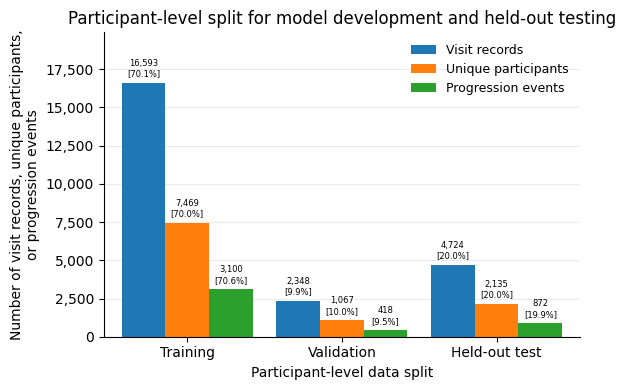

Figure 1. Participant-level train, validation, and held-out test split. Bars show visit records, unique participants, and next-visit dementia progression events. Bracketed values indicate the percentage of each quantity represented by the corresponding split.

Saved figure to: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/2_patient_level_splits/fig1_patient_level_split_counts.png
Saved figure to: /home/ppanta/puru_proj/1_dementia_progress/dementia_progress_v0/op/2_patient_level_splits/fig1_patient_level_split_counts.pdf


In [4]:
plot_df = table1.loc[table1["Split"] != "Total", ["Split", "Visits", "Participants", "Events", "% of visits", "% of participants", "% of events"]].copy()

metrics = [
    ("Visits", "% of visits", "Visit records"),
    ("Participants", "% of participants", "Unique participants"),
    ("Events", "% of events", "Progression events"),
]

group_spacing = 0.78  # smaller value reduces space between Training, Validation, and Held-out test groups
x = np.arange(len(plot_df)) * group_spacing
width = 0.22
bar_offsets = np.array([-width, 0, width])

fig, ax = plt.subplots(figsize=(6.0, 4.0))

bars_by_metric = []
for idx, (count_col, pct_col, label) in enumerate(metrics):
    bars_handle = ax.bar(
        x + bar_offsets[idx],
        plot_df[count_col],
        width=width,
        label=label,
    )
    bars_by_metric.append((bars_handle, count_col, pct_col))

max_y = plot_df[[m[0] for m in metrics]].to_numpy().max()
ax.set_ylim(0, max_y * 1.20)

for bars_handle, count_col, pct_col in bars_by_metric:
    for bar, (_, row) in zip(bars_handle, plot_df.iterrows()):
        h = bar.get_height()
        label_text = f"{int(h):,}" + chr(10) + f"[{row[pct_col]:.1f}%]"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + max_y * 0.018,
            label_text,
            ha="center",
            va="bottom",
            fontsize=6,
        )

ax.set_xticks(x)
ax.set_xticklabels(plot_df["Split"], fontsize=10)
ax.set_xlim(x[0] - 0.42, x[-1] + 0.42)
ax.set_ylabel("Number of visit records, unique participants,\nor progression events")
ax.set_xlabel("Participant-level data split")
ax.set_title("Participant-level split for model development and held-out testing")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="upper right", frameon=False, fontsize=9)

fig.tight_layout()

fig_png = OUTPUT_DIR / "fig1_patient_level_split_counts.png"
fig_pdf = OUTPUT_DIR / "fig1_patient_level_split_counts.pdf"
fig.savefig(fig_png, dpi=300, bbox_inches="tight")
fig.savefig(fig_pdf, bbox_inches="tight")
plt.show()

caption = (
    "Figure 1. Participant-level train, validation, and held-out test split. "
    "Bars show visit records, unique participants, and next-visit dementia progression events. "
    "Bracketed values indicate the percentage of each quantity represented by the corresponding split."
)
(OUTPUT_DIR / "fig1_patient_level_split_counts_caption.txt").write_text(caption + "\n", encoding="utf-8")

display(Markdown(caption))
print("Saved figure to:", fig_png)
print("Saved figure to:", fig_pdf)


## Participant-leakage check

The split summary includes overlap checks across the participant-level train, validation, and held-out test sets. Values of zero indicate that the same participant was not present across those split boundaries.

In [5]:
leak_cols = [
    "train_validation_overlap_participants",
    "train_test_overlap_participants",
    "validation_test_overlap_participants",
    "participant_leakage_detected",
]

available_leak_cols = [c for c in leak_cols if c in raw_split.columns]
leak_summary = raw_split.loc[raw_split["split"].isin(split_order), ["split"] + available_leak_cols].copy()
leak_summary["Split"] = leak_summary["split"].map(split_display)
leak_summary = leak_summary.drop(columns=["split"])

display(Markdown("**Participant-overlap and leakage checks**"))
display(leak_summary)
leak_summary.to_csv(OUTPUT_DIR / "patient_level_split_leakage_checks.csv", index=False)

if available_leak_cols:
    total_leak_flags = int(leak_summary[available_leak_cols].sum().sum())
    if total_leak_flags == 0:
        print("No participant overlap or leakage was detected across the primary split boundaries.")
    else:
        print("Warning: participant overlap/leakage flags were detected. Review the leakage table.")


**Participant-overlap and leakage checks**

,train_validation_overlap_participants,train_test_overlap_participants,validation_test_overlap_participants,participant_leakage_detected,Split
0,0,0,0,0,Training
1,0,0,0,0,Validation
2,0,0,0,0,Held-out test


No participant overlap or leakage was detected across the primary split boundaries.
